In [1]:
# Market Regime Forecasting Project
# DADS7275 - Raunak Amanna

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'stable': '#2196F3', 'highrisk': '#F44336', 'neutral': '#607D8B'}

print("Libraries loaded.")


Libraries loaded.


In [2]:
# Download SPY and VIX data from Yahoo Finance
START, END = '2000-01-01', '2025-01-01'

raw_spy = yf.download('SPY', start=START, end=END, auto_adjust=True)
raw_vix = yf.download('^VIX', start=START, end=END, auto_adjust=True)

spy = raw_spy['Close'].squeeze()
vix = raw_vix['Close'].squeeze()

df = pd.DataFrame({'Price': spy, 'VIX': vix}).dropna()

print("Shape:", df.shape)
print("Dates:", df.index[0].date(), "to", df.index[-1].date())
print(df.head())
print(df.describe().round(2))


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape: (6289, 2)
Dates: 2000-01-03 to 2024-12-31
                Price        VIX
Date                            
2000-01-03  91.367546  24.209999
2000-01-04  87.794495  27.010000
2000-01-05  87.951569  26.410000
2000-01-06  86.538048  25.730000
2000-01-07  91.563858  21.719999
         Price      VIX
count  6289.00  6289.00
mean    179.35    19.87
std     129.98     8.46
min      49.81     9.14
25%      83.76    13.86
50%     109.46    17.84
75%     244.60    23.36
max     597.11    82.69


In [3]:
# Feature engineering

# moving averages
df['SMA_50']  = df['Price'].rolling(50).mean()
df['SMA_200'] = df['Price'].rolling(200).mean()
df['SMA_50_Dist']  = (df['Price'] - df['SMA_50'])  / df['SMA_50']
df['SMA_200_Dist'] = (df['Price'] - df['SMA_200']) / df['SMA_200']

# RSI
delta = df['Price'].diff()
gain  = delta.where(delta > 0, 0.0).rolling(14).mean()
loss  = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

# daily returns
df['Returns'] = df['Price'].pct_change()

# target: VIX > 20 means high risk, shift by -1 so today predicts tomorrow
df['Regime_Current']  = np.where(df['VIX'] > 20.0, 1, 0)
df['Target_Next_Day'] = df['Regime_Current'].shift(-1)

df.dropna(inplace=True)
df['Target_Next_Day'] = df['Target_Next_Day'].astype(int)

FEATURES = ['RSI', 'Returns', 'SMA_50_Dist', 'SMA_200_Dist']

print("Shape:", df.shape)
print("Features:", FEATURES)
print(df['Target_Next_Day'].value_counts())
print("High risk %:", round(df['Target_Next_Day'].mean()*100, 1))


Shape: (6089, 10)
Features: ['RSI', 'Returns', 'SMA_50_Dist', 'SMA_200_Dist']
Target_Next_Day
0    3788
1    2301
Name: count, dtype: int64
High risk %: 37.8


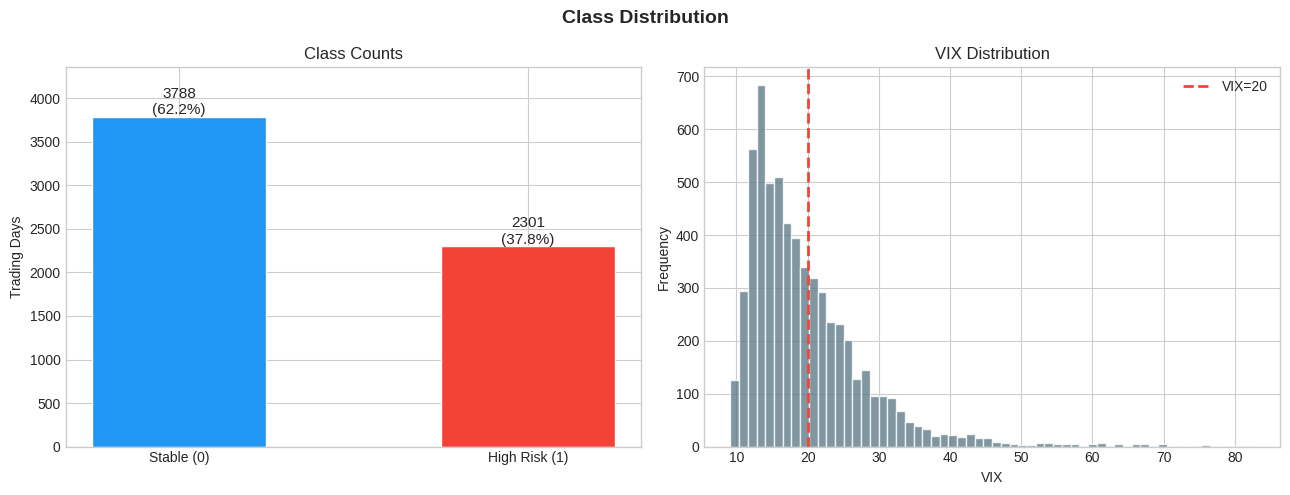

Stable: 3788 | High Risk: 2301
Ratio: 1.65


In [4]:
# EDA plot 1: class balance

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Distribution", fontsize=14, fontweight='bold')

counts = df['Target_Next_Day'].value_counts().sort_index()
bars = axes[0].bar(['Stable (0)', 'High Risk (1)'], counts.values,
                   color=[COLORS['stable'], COLORS['highrisk']], edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=11)
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Trading Days")
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].hist(df['VIX'], bins=60, color=COLORS['neutral'], edgecolor='white', alpha=0.8)
axes[1].axvline(20, color=COLORS['highrisk'], linewidth=2, linestyle='--', label='VIX=20')
axes[1].set_title("VIX Distribution")
axes[1].set_xlabel("VIX")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_1_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("Stable:", counts[0], "| High Risk:", counts[1])
print("Ratio:", round(counts[0]/counts[1], 2))


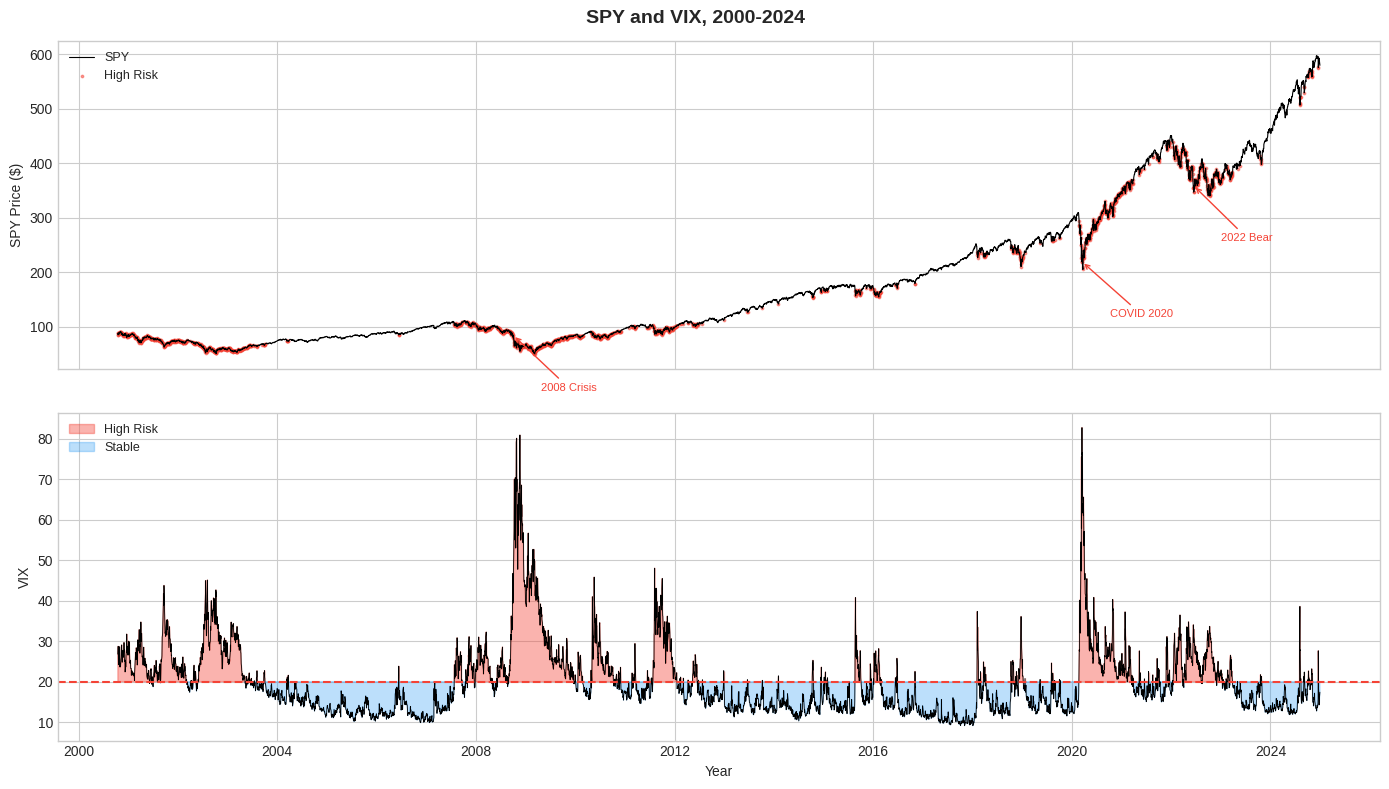

In [5]:
# EDA plot 2: SPY price and VIX over time

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("SPY and VIX, 2000-2024", fontsize=14, fontweight='bold')

ax1.plot(df.index, df['Price'], color='black', linewidth=0.8, label='SPY')
crash_days = df[df['Regime_Current'] == 1]
ax1.scatter(crash_days.index, crash_days['Price'],
            color=COLORS['highrisk'], s=3, alpha=0.5, label='High Risk')
ax1.set_ylabel("SPY Price ($)")
ax1.legend(loc='upper left', fontsize=9)

events = {'2008 Crisis': '2008-10-01', 'COVID 2020': '2020-03-15', '2022 Bear': '2022-06-15'}
for label, date in events.items():
    try:
        idx = df.index.searchsorted(pd.Timestamp(date))
        ax1.annotate(label, xy=(df.index[idx], df['Price'].iloc[idx]),
                     xytext=(20, -40), textcoords='offset points',
                     fontsize=8, color=COLORS['highrisk'],
                     arrowprops=dict(arrowstyle='->', color=COLORS['highrisk'], lw=1))
    except Exception:
        pass

ax2.fill_between(df.index, df['VIX'], 20, where=(df['VIX'] > 20),
                 color=COLORS['highrisk'], alpha=0.4, label='High Risk')
ax2.fill_between(df.index, df['VIX'], 20, where=(df['VIX'] <= 20),
                 color=COLORS['stable'], alpha=0.3, label='Stable')
ax2.plot(df.index, df['VIX'], color='black', linewidth=0.6)
ax2.axhline(20, color=COLORS['highrisk'], linewidth=1.5, linestyle='--')
ax2.set_ylabel("VIX")
ax2.set_xlabel("Year")
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig("eda_2_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()


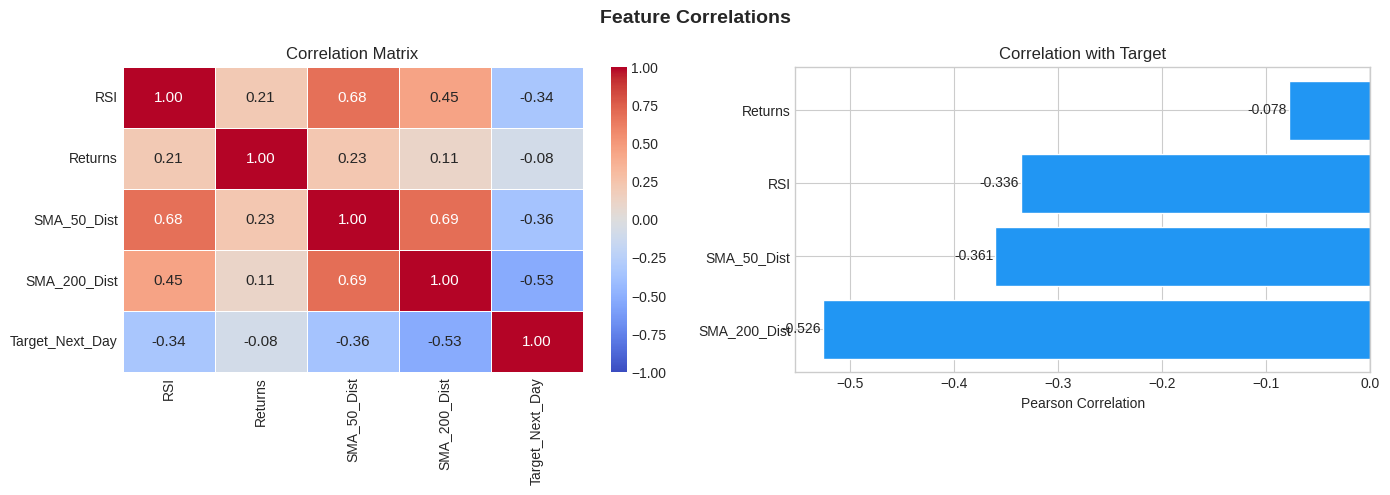

Correlations with target:
  RSI: -0.3360
  Returns: -0.0785
  SMA_50_Dist: -0.3606
  SMA_200_Dist: -0.5263


In [6]:
# EDA plot 3: correlations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Correlations", fontsize=14, fontweight='bold')

corr = df[FEATURES + ['Target_Next_Day']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 11})
axes[0].set_title("Correlation Matrix")

target_corr = corr['Target_Next_Day'].drop('Target_Next_Day').sort_values()
colors = [COLORS['highrisk'] if v > 0 else COLORS['stable'] for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Correlation with Target")
axes[1].set_xlabel("Pearson Correlation")
for i, v in enumerate(target_corr.values):
    axes[1].text(v + (0.002 if v >= 0 else -0.002), i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig("eda_3_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

print("Correlations with target:")
for feat, val in corr['Target_Next_Day'].drop('Target_Next_Day').items():
    print(f"  {feat}: {val:+.4f}")


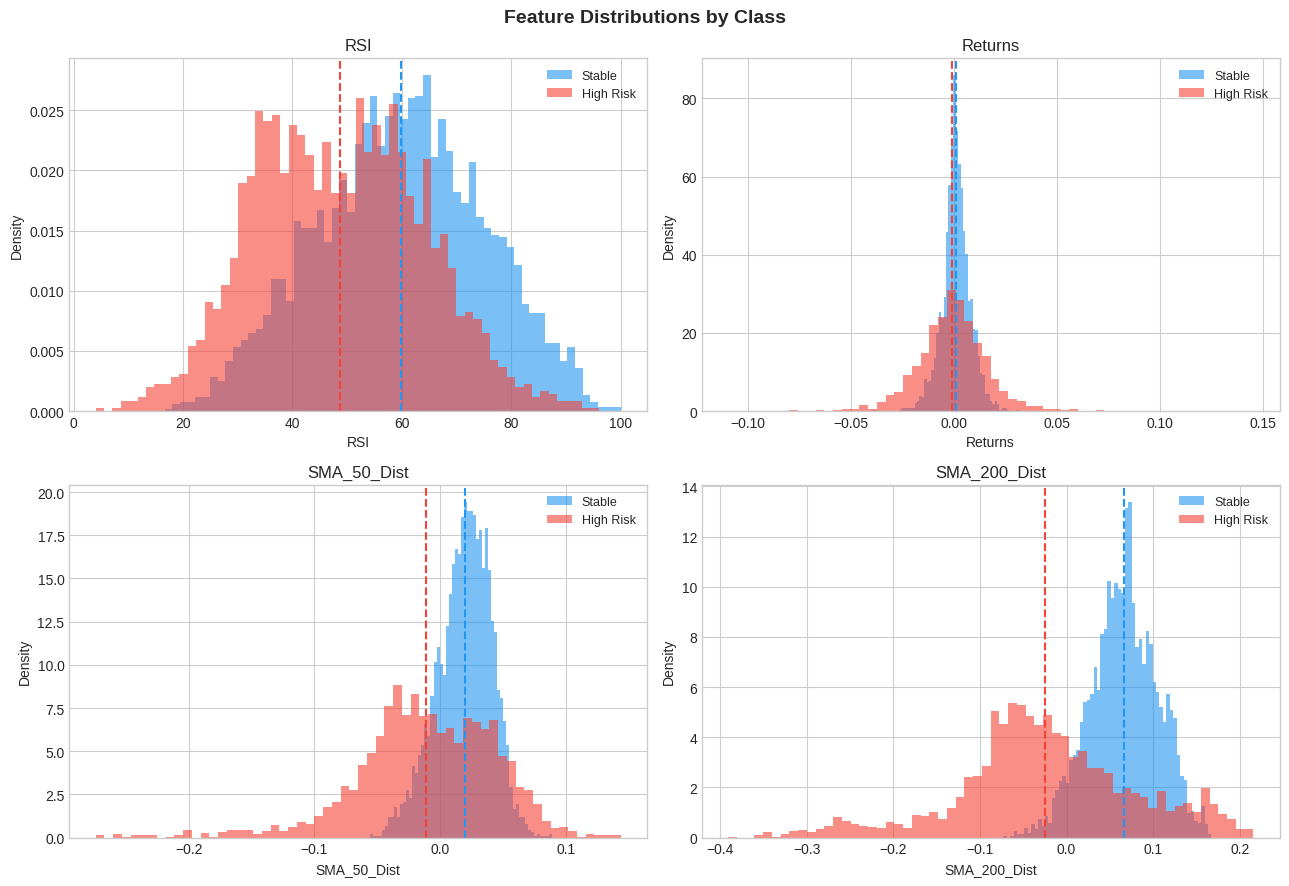

RSI: stable mean=+59.7974, high risk mean=+48.6101
Returns: stable mean=+0.0011, high risk mean=-0.0008
SMA_50_Dist: stable mean=+0.0193, high risk mean=-0.0109
SMA_200_Dist: stable mean=+0.0658, high risk mean=-0.0246


In [7]:
# EDA plot 4: feature distributions by class

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Feature Distributions by Class", fontsize=14, fontweight='bold')

stable    = df[df['Target_Next_Day'] == 0]
high_risk = df[df['Target_Next_Day'] == 1]

for ax, feat in zip(axes.flat, FEATURES):
    ax.hist(stable[feat], bins=60, alpha=0.6, color=COLORS['stable'],
            label='Stable', density=True, edgecolor='none')
    ax.hist(high_risk[feat], bins=60, alpha=0.6, color=COLORS['highrisk'],
            label='High Risk', density=True, edgecolor='none')
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.axvline(stable[feat].mean(), color=COLORS['stable'], linestyle='--', linewidth=1.5)
    ax.axvline(high_risk[feat].mean(), color=COLORS['highrisk'], linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.savefig("eda_4_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

for feat in FEATURES:
    print(f"{feat}: stable mean={stable[feat].mean():+.4f}, high risk mean={high_risk[feat].mean():+.4f}")


In [8]:
# Split data and scale

SPLIT_DATE = '2020-01-01'

train_df = df[df.index <  SPLIT_DATE]
test_df  = df[df.index >= SPLIT_DATE]

X_train = train_df[FEATURES]
y_train = train_df['Target_Next_Day']
X_test  = test_df[FEATURES]
y_test  = test_df['Target_Next_Day']

print("Train:", X_train.shape[0], "days")
print("Test:", X_test.shape[0], "days")
print("Train high risk %:", round(y_train.mean()*100, 1))
print("Test high risk %:", round(y_test.mean()*100, 1))

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


# helper functions
def evaluate_model(name, y_true, y_pred, y_prob=None):
    report = classification_report(y_true, y_pred, output_dict=True)
    print(f"\n{name}")
    print(classification_report(y_true, y_pred, target_names=['Stable','High Risk']))
    return {
        'name': name,
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1': report['1']['f1-score'],
        'accuracy': report['accuracy'],
        'y_pred': y_pred,
        'y_prob': y_prob,
    }


def plot_confusion_matrix(results, y_true):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, res in zip(axes, results):
        cm = confusion_matrix(y_true, res['y_pred'])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Stable', 'High Risk'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"{res['name']}\nRecall: {res['recall']:.2f} | Precision: {res['precision']:.2f}")
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
    plt.show()


all_results = []

# dummy baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_sc, y_train)
dummy_pred = dummy.predict(X_test_sc)
res_dummy = evaluate_model("Dummy", y_test, dummy_pred)
all_results.append(res_dummy)


Train: 4832 days
Test: 1257 days
Train high risk %: 35.1
Test high risk %: 48.1

Dummy
              precision    recall  f1-score   support

      Stable       0.52      1.00      0.68       653
   High Risk       0.00      0.00      0.00       604

    accuracy                           0.52      1257
   macro avg       0.26      0.50      0.34      1257
weighted avg       0.27      0.52      0.36      1257



In [9]:
# Model 1: Logistic Regression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

res_lr = evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
all_results.append(res_lr)

coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Coefficients:")
for _, row in coef_df.iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:+.4f}")



Logistic Regression
              precision    recall  f1-score   support

      Stable       0.69      0.95      0.80       653
   High Risk       0.91      0.54      0.68       604

    accuracy                           0.75      1257
   macro avg       0.80      0.74      0.74      1257
weighted avg       0.79      0.75      0.74      1257

Coefficients:
  SMA_200_Dist: -1.6452
  RSI: -0.4902
  SMA_50_Dist: +0.3002
  Returns: -0.0256



Random Forest
              precision    recall  f1-score   support

      Stable       0.71      0.93      0.81       653
   High Risk       0.89      0.59      0.71       604

    accuracy                           0.77      1257
   macro avg       0.80      0.76      0.76      1257
weighted avg       0.80      0.77      0.76      1257



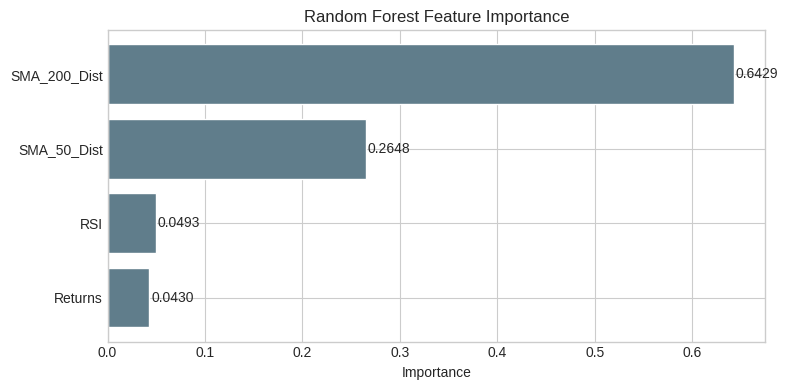

In [10]:
# Model 2: Random Forest

rf = RandomForestClassifier(n_estimators=100, max_depth=5,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rf_pred = rf.predict(X_test_sc)
rf_prob = rf.predict_proba(X_test_sc)[:, 1]

res_rf = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
all_results.append(res_rf)

importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=COLORS['neutral'], edgecolor='white')
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Model 3: SVM

svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train_sc, y_train)
svm_pred = svm.predict(X_test_sc)
svm_prob = svm.predict_proba(X_test_sc)[:, 1]

res_svm = evaluate_model("SVM", y_test, svm_pred, svm_prob)
all_results.append(res_svm)



SVM
              precision    recall  f1-score   support

      Stable       0.74      0.92      0.82       653
   High Risk       0.88      0.66      0.75       604

    accuracy                           0.79      1257
   macro avg       0.81      0.79      0.79      1257
weighted avg       0.81      0.79      0.79      1257



In [12]:
# Make sequences for LSTM

WINDOW = 10

def create_sequences(X, y, window):
    X_seq, y_seq = [], []
    for i in range(window, len(X)):
        X_seq.append(X[i-window:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_sc, y_train.values, WINDOW)
X_test_seq, y_test_seq = create_sequences(X_test_sc, y_test.values, WINDOW)

print("Window:", WINDOW)
print("X_train_seq:", X_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)


Window: 10
X_train_seq: (4822, 10, 4)
X_test_seq: (1247, 10, 4)


In [13]:
# Model 4: LSTM

lstm_model = Sequential([
    LSTM(32, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(X_train_seq, y_train_seq,
                         validation_split=0.2,
                         epochs=30, batch_size=32,
                         callbacks=[early_stop], verbose=1)

lstm_prob = lstm_model.predict(X_test_seq).ravel()
lstm_pred = (lstm_prob >= 0.5).astype(int)

res_lstm = evaluate_model("LSTM", y_test_seq, lstm_pred, lstm_prob)
all_results.append(res_lstm)


Epoch 1/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8170 - loss: 0.4668 - val_accuracy: 0.8902 - val_loss: 0.3457
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8558 - loss: 0.3387 - val_accuracy: 0.8487 - val_loss: 0.3136
Epoch 3/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8748 - loss: 0.3009 - val_accuracy: 0.8539 - val_loss: 0.2930
Epoch 4/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8916 - loss: 0.2773 - val_accuracy: 0.8715 - val_loss: 0.2742
Epoch 5/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8986 - loss: 0.2570 - val_accuracy: 0.8839 - val_loss: 0.2692
Epoch 6/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9012 - loss: 0.2448 - val_accuracy: 0.8891 - val_loss: 0.2665
Epoch 7/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9077 - loss: 0.2358 - val_accuracy: 0.8798 - val_loss: 0.2796
Epoch 8/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9082 - loss: 0.2319 - val_accuracy: 

In [14]:
# Try different thresholds for Random Forest

for t in [0.30, 0.40, 0.50, 0.60]:
    rf_pred_t = (rf_prob >= t).astype(int)
    report = classification_report(y_test, rf_pred_t, output_dict=True)
    print(f"Threshold {t}: precision={report['1']['precision']:.3f}, recall={report['1']['recall']:.3f}, f1={report['1']['f1-score']:.3f}")


Threshold 0.3: precision=0.798, recall=0.720, f1=0.757
Threshold 0.4: precision=0.871, recall=0.662, f1=0.753
Threshold 0.5: precision=0.892, recall=0.591, f1=0.711
Threshold 0.6: precision=0.913, recall=0.553, f1=0.689


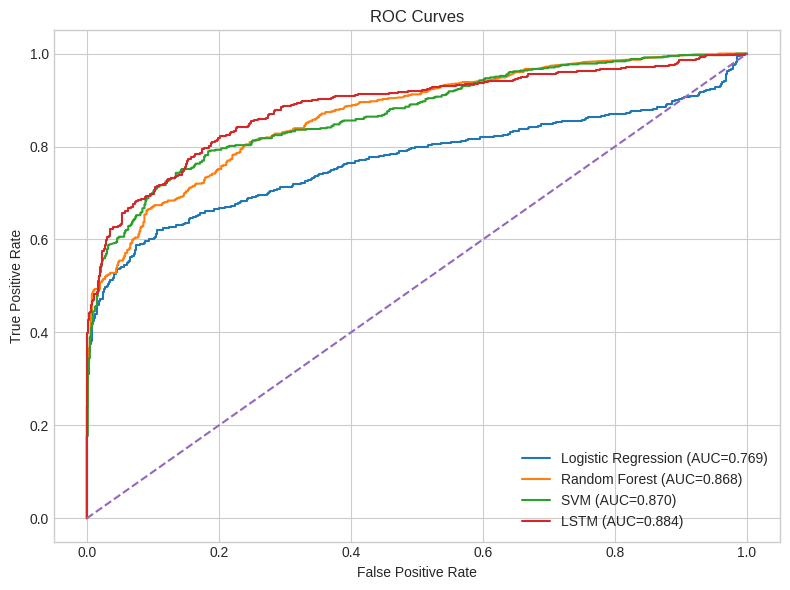

In [15]:
# ROC curves

plt.figure(figsize=(8, 6))

for res in [res_lr, res_rf, res_svm]:
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{res['name']} (AUC={roc_auc:.3f})")

lstm_fpr, lstm_tpr, _ = roc_curve(y_test_seq, res_lstm['y_prob'])
lstm_auc = auc(lstm_fpr, lstm_tpr)
plt.plot(lstm_fpr, lstm_tpr, label=f"LSTM (AUC={lstm_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()


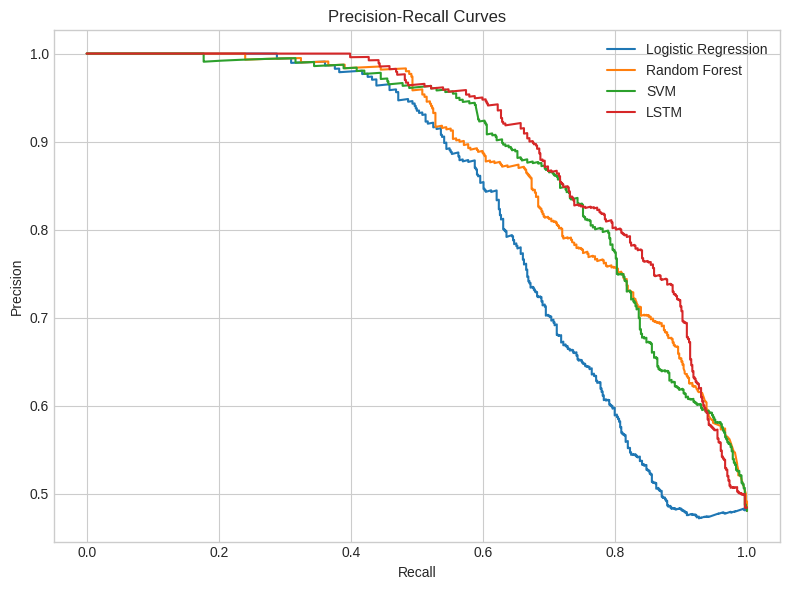

In [16]:
# Precision-Recall curves

plt.figure(figsize=(8, 6))

for res in [res_lr, res_rf, res_svm]:
    if res['y_prob'] is not None:
        precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
        plt.plot(recall, precision, label=res['name'])

precision_lstm, recall_lstm, _ = precision_recall_curve(y_test_seq, res_lstm['y_prob'])
plt.plot(recall_lstm, precision_lstm, label='LSTM')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_curves.png", dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# Final comparison table

results_table = pd.DataFrame([
    {'Model': r['name'],
     'Accuracy': r['accuracy'],
     'Precision': r['precision'],
     'Recall': r['recall'],
     'F1': r['f1']}
    for r in all_results
])

results_table = results_table.sort_values(by='Recall', ascending=False).reset_index(drop=True)
print(results_table.round(4))
results_table.to_csv("final_model_comparison.csv", index=False)


                 Model  Accuracy  Precision  Recall      F1
0                 LSTM    0.8035     0.8499  0.7219  0.7807
1                  SVM    0.7932     0.8822  0.6573  0.7533
2        Random Forest    0.7693     0.8925  0.5911  0.7112
3  Logistic Regression    0.7526     0.9058  0.5414  0.6777
4                Dummy    0.5195     0.0000  0.0000  0.0000


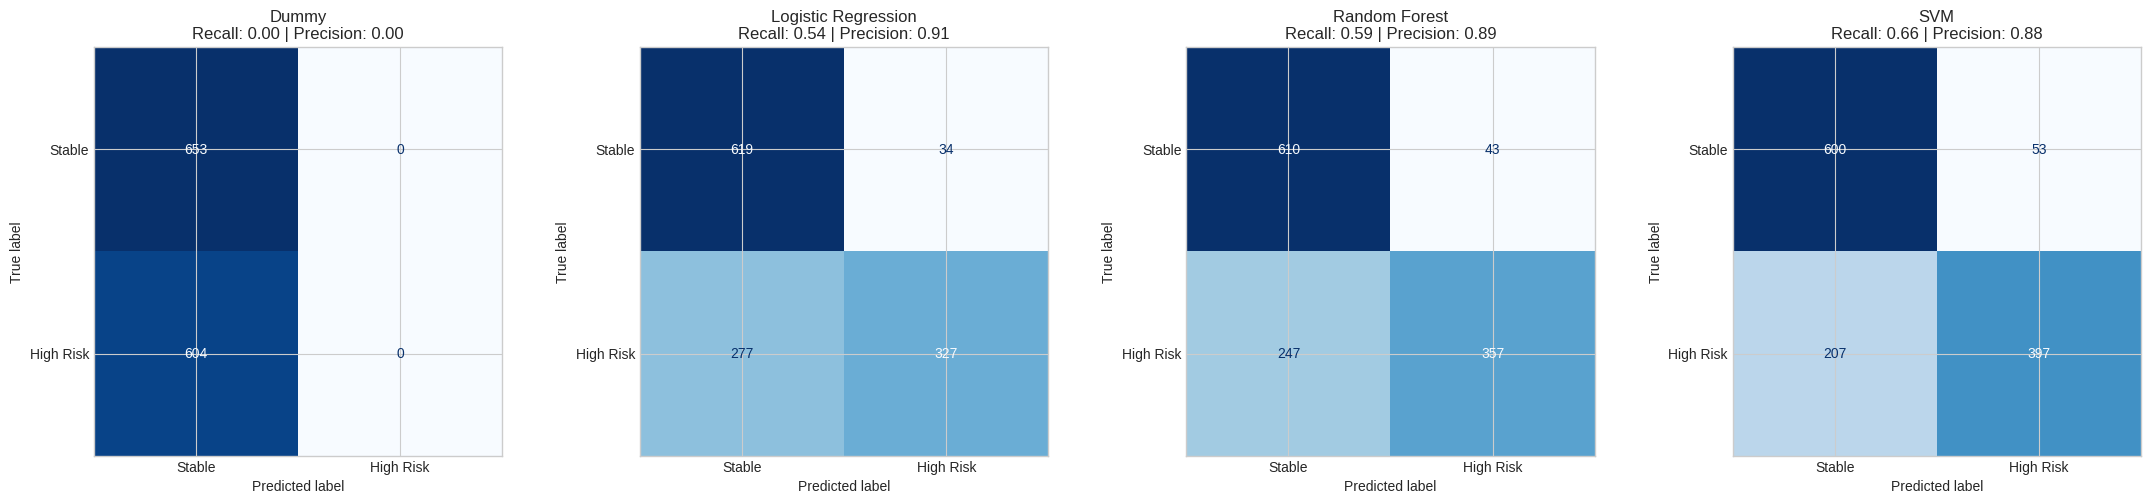

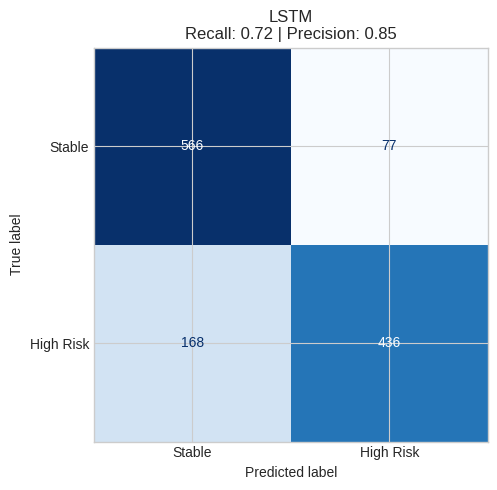

In [18]:
# Confusion matrices

traditional_results = [res_dummy, res_lr, res_rf, res_svm]
plot_confusion_matrix(traditional_results, y_test)

plot_confusion_matrix([res_lstm], y_test_seq)
